In [12]:
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor

from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s16t3_ames_housing.csv')

In [5]:
# список всех категориальных признаков
cat_columns = ["Neighborhood", "Bsmt Qual", "Kitchen Qual", "Exter Qual"]

for col in cat_columns:
    df[col] = df[col].astype('category')

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2850 entries, 0 to 2849
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Overall Qual    2850 non-null   int64   
 1   Gr Liv Area     2850 non-null   int64   
 2   Neighborhood    2850 non-null   category
 3   Bsmt Qual       2850 non-null   category
 4   Total Bsmt SF   2850 non-null   float64 
 5   Kitchen Qual    2850 non-null   category
 6   1st Flr SF      2850 non-null   int64   
 7   2nd Flr SF      2850 non-null   int64   
 8   Exter Qual      2850 non-null   category
 9   Year Built      2850 non-null   int64   
 10  Year Remod/Add  2850 non-null   int64   
 11  Lot Area        2850 non-null   int64   
 12  SalePrice       2850 non-null   int64   
dtypes: category(4), float64(1), int64(8)
memory usage: 212.0 KB
None


In [21]:
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

# Определяем выборки
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.2
)
X_train_cal, X_val, y_train_cal, y_val = train_test_split(
    X, y,
    test_size=0.2
)
X_train, X_cal, y_train, y_cal = train_test_split(
    X, y,
    test_size=0.2
)

In [13]:
# инициализируем XGBRegressor с поддержкой обработки категориальных признаков
xgb_model_base = XGBRegressor(
    random_state=42,
    enable_categorical=True
)

# обучаем модель на обучающей выборке
xgb_model_base.fit(X_train, y_train)

# получаем предсказания по тестовым объектам
y_pred = xgb_model_base.predict(X_test)

# рассчитываем значение метрики rmse
rmse = root_mean_squared_error(y_test, y_pred)

print(f"Значение RMSE на тестовой выборке: {rmse:.2f}")

Значение RMSE на тестовой выборке: 11100.30


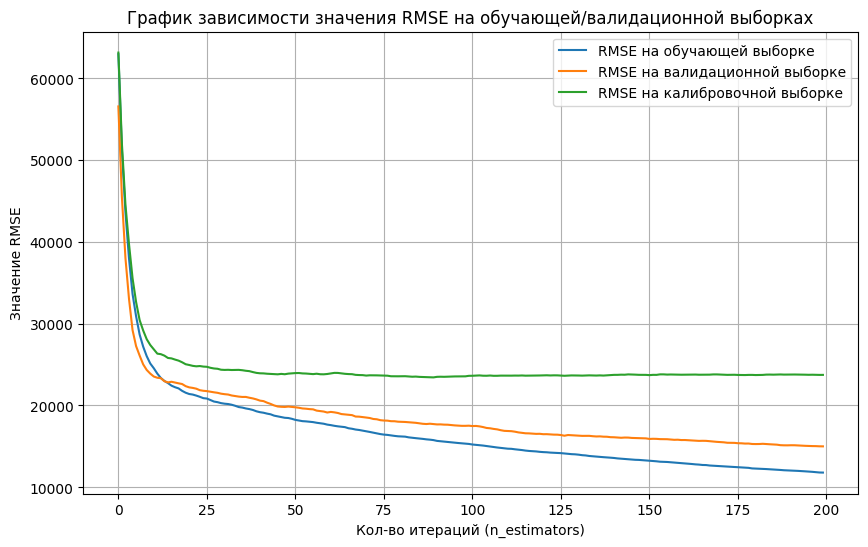

In [27]:
xgb_model = XGBRegressor(
    max_depth=3,
    n_estimators=200,
    learning_rate=0.3,
    random_state=42,
    enable_categorical=True,
    eval_metric='rmse'
)

# Обучаем модель с eval_set
xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val), (X_cal, y_cal)],
    verbose=False
)

# Достаём значения метрики rmse на каждой итерации обучения
results = xgb_model.evals_result()
epochs = len(results['validation_0']['rmse'])
x = range(epochs)

# Строим график
plt.figure(figsize=(10, 6))
plt.plot(x, results['validation_0']['rmse'], label='RMSE на обучающей выборке')
plt.plot(x, results['validation_1']['rmse'], label='RMSE на валидационной выборке')
plt.plot(x, results['validation_2']['rmse'], label='RMSE на калибровочной выборке')
plt.xlabel('Кол-во итераций (n_estimators)')
plt.ylabel('Значение RMSE')
plt.title('График зависимости значения RMSE на обучающей/валидационной выборках')
plt.legend()
plt.grid(True)
plt.show()